# Reentrenamiento de la red FC con image augmentation

**Requisitos para correr este notebook:**
- `asl-alphabet/processed/asl_64x64_600pc.npz` debe existir (generado por `preprocesamiento.ipynb`).
- `augmentation.py` debe estar en la misma carpeta que este notebook.
- `models/FC_simple.keras` debe existir (generado por `redesNeuronalesSimple.ipynb`) — si no existe, esta celda lo indicará y el notebook sigue funcionando, solo que sin el número de comparación.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers, models
from keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

keras.utils.set_random_seed(43)

## 1. Cargar los datos preprocesados

In [2]:
DATA_PATH = Path("asl-alphabet/processed/asl_64x64_600pc.npz")
assert DATA_PATH.exists(), f"No se encontró {DATA_PATH}. Corre primero preprocesamiento.ipynb"

data = np.load(DATA_PATH, allow_pickle=True)

X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val = data["X_val"], data["y_val"]
X_test, y_test = data["X_test"], data["y_test"]
class_names = data["class_names"]
n_classes = len(class_names)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)
print("Clases:", n_classes)

Train: (12180, 64, 64, 3) (12180,)
Val:   (2610, 64, 64, 3) (2610,)
Test:  (2610, 64, 64, 3) (2610,)
Clases: 29


## 2. Preparar los datos sin aplanar

Las capas de augmentation (rotar, hacer zoom, etc.) necesitan la imagen en su forma original `(64,64,3)` — no se puede rotar un vector ya aplanado. El aplanado se mueve *adentro* del modelo, después de la capa de augmentation.

In [3]:
X_train_img = X_train.astype(np.float32) / 255.0
X_val_img   = X_val.astype(np.float32) / 255.0
X_test_img  = X_test.astype(np.float32) / 255.0

print(X_train_img.shape, X_val_img.shape, X_test_img.shape)

(12180, 64, 64, 3) (2610, 64, 64, 3) (2610, 64, 64, 3)


## 3. Modelo con augmentation



In [4]:
from augmentation import get_augmentation_pipeline

data_augmentation = get_augmentation_pipeline()

model_fc_aug = models.Sequential([
    layers.Input(shape=(64, 64, 3)),
    data_augmentation,
    layers.Flatten(),
    layers.Dense(512, activation="relu", kernel_initializer="he_normal"),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu", kernel_initializer="he_normal"),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation="softmax"),
])

model_fc_aug.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model_fc_aug.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ asl_data_augmentation           │ (None, 64, 64, 3)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,361,373 (24.27 MB)

 Trainable params: 6,361,373 (24.27 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
early_stop_aug = EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)

history_aug = model_fc_aug.fit(
    X_train_img, y_train,
    validation_data=(X_val_img, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop_aug],
)

Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 56s 292ms/step - accuracy: 0.0341 - loss: 3.5246 - val_accuracy: 0.0345 - val_loss: 3.3673
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 58s 306ms/step - accuracy: 0.0383 - loss: 3.3536 - val_accuracy: 0.0479 - val_loss: 3.3151
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 60s 313ms/step - accuracy: 0.0398 - loss: 3.3335 - val_accuracy: 0.0398 - val_loss: 3.2880
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 61s 320ms/step - accuracy: 0.0420 - loss: 3.3281 - val_accuracy: 0.0552 - val_loss: 3.2881
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 68s 356ms/step - accuracy: 0.0414 - loss: 3.3197 - val_accuracy: 0.0575 - val_loss: 3.2611
Epoch 6/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 64s 334ms/step - accuracy: 0.0418 - loss: 3.3214 - val_accuracy: 0.0590 - val_loss: 3.2767
Epoch 7/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 61s 322ms/step - accuracy: 0.0443 - loss: 3.3165 - val_accuracy: 0.0613 - val_loss: 3.2531
Epoch 8/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 61s 320ms/step - accuracy: 0.0433 - loss: 3

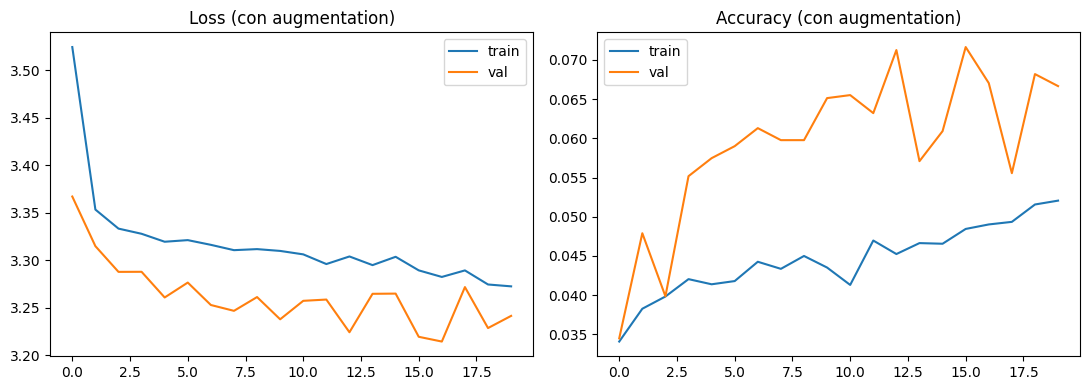

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_aug.history["loss"], label="train")
axes[0].plot(history_aug.history["val_loss"], label="val")
axes[0].set_title("Loss (con augmentation)"); axes[0].legend()

axes[1].plot(history_aug.history["accuracy"], label="train")
axes[1].plot(history_aug.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy (con augmentation)"); axes[1].legend()
plt.tight_layout()
plt.show()

In [7]:
test_loss_aug, test_acc_aug = model_fc_aug.evaluate(X_test_img, y_test)
print(f"Test accuracy FC (con augmentation): {test_acc_aug:.4f}")

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0736 - loss: 3.2040
Test accuracy FC (con augmentation): 0.0736


## 4. Comparar contra el modelo ya entrenado sin augmentation



In [8]:
MODELS_DIR = Path("models")
baseline_path = MODELS_DIR / "FC_simple.keras"

if baseline_path.exists():
    model_fc = keras.models.load_model(baseline_path)
    # El modelo base espera el input aplanado (N, 12288)
    X_test_flat = X_test.astype(np.float32).reshape(len(X_test), -1) / 255.0
    test_loss, test_acc = model_fc.evaluate(X_test_flat, y_test)

    print(f"Test accuracy SIN augmentation: {test_acc:.4f}")
    print(f"Test accuracy CON augmentation: {test_acc_aug:.4f}")
    print(f"Diferencia: {test_acc_aug - test_acc:+.4f}")
else:
    test_acc = None
    print(f"No se encontró {baseline_path} — corre primero redesNeuronalesSimple.ipynb para tener el modelo base.")
    print(f"Test accuracy CON augmentation: {test_acc_aug:.4f}")

82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1169 - loss: 2.8481
Test accuracy SIN augmentation: 0.1169
Test accuracy CON augmentation: 0.0736
Diferencia: -0.0433


### Comparación: red FC con y sin augmentation

| Modelo | Accuracy en test | Diferencia |
|---|---|---|
| Red FC (sin augmentation) | 11.69% | — |
| Red FC (con augmentation) | 7.36% | **-4.33 puntos** |

**El augmentation empeoró el resultado**, contrario a lo que se esperaría intuitivamente. Hay dos factores que explican esto:

**1. Limitación estructural de la red FC.** Como se discutió en el Ejercicio 5, esta arquitectura ya pierde toda la información espacial al aplanar la imagen antes de las capas densas. El augmentation añade variabilidad geométrica (rotación, zoom, traslación) que una CNN puede aprovechar porque sus filtros convolucionales sí preservan relaciones espaciales — pero para una red FC, esa variabilidad adicional solo hace el problema más difícil de aprender, sin ninguna ventaja estructural que la compense. En lugar de ayudar a generalizar, el augmentation le agrega ruido a un modelo que ya tenía dificultad para aprender el patrón base.

**Conclusión:** para la red FC, el image augmentation no resultó beneficioso — refuerza la idea de que el cuello de botella de este modelo es la arquitectura (pérdida de estructura espacial), no la cantidad o variabilidad de los datos de entrenamiento. Esto contrasta con lo esperable en las CNNs (Ejercicio 4), donde el augmentation sí debería ayudar a generalizar mejor, precisamente porque esos modelos pueden aprovechar la variabilidad geométrica sin perder la relación espacial entre píxeles.